Базовые метрики пупупу
Всего кофеен: 456
Средний рейтинг: 4.50 (±0.60)
Медианный рейтинг: 4.70
Доля с веб-сайтом: 80.0%
Доля с телефоном: 86.4%


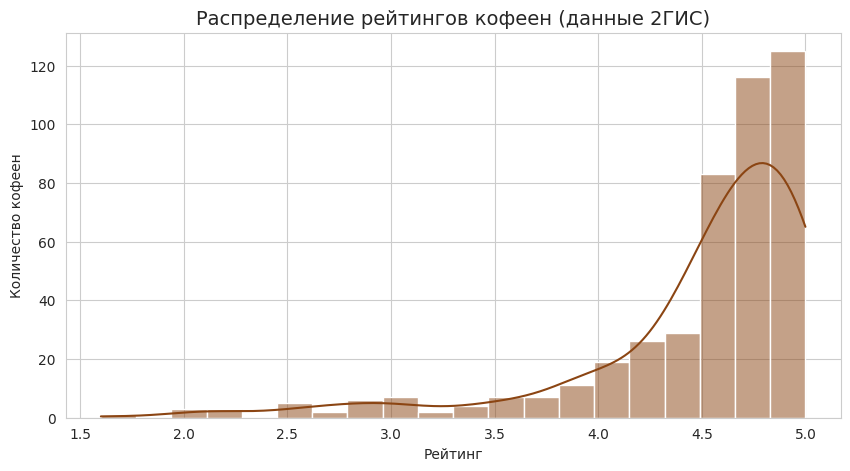

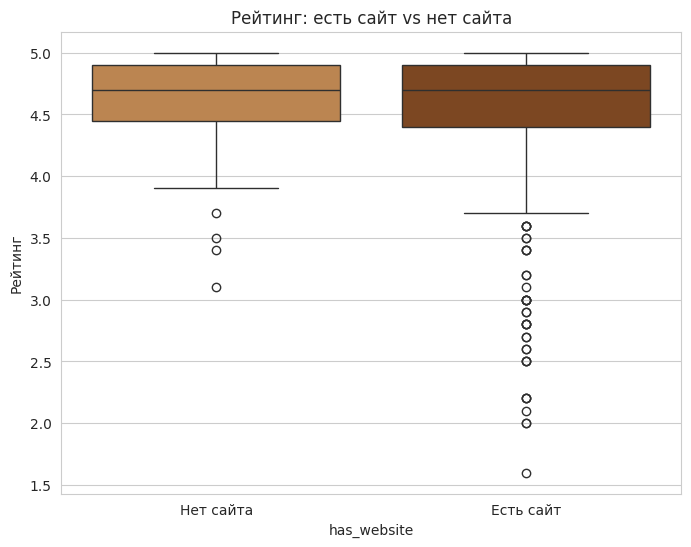

T-test p-value: 0.0454
Разница статистически значима: кофейни с сайтом имеют более высокий рейтинг.


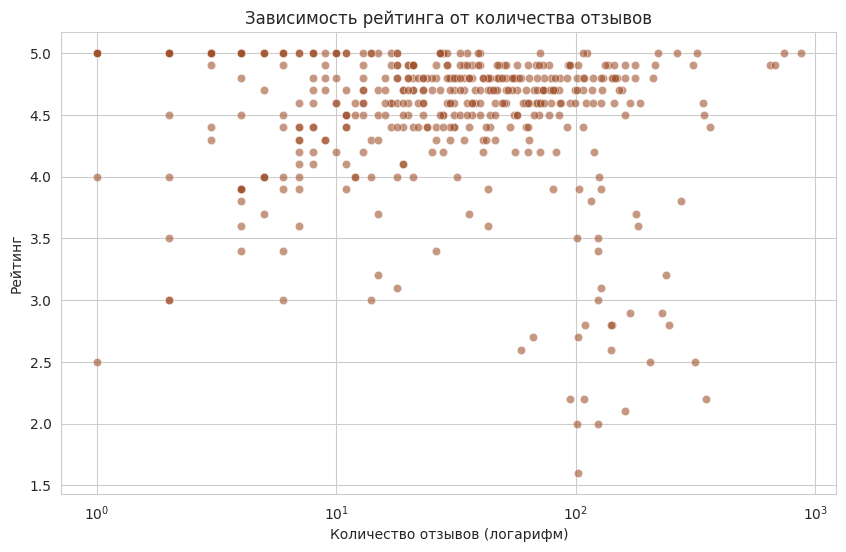

Корреляция Пирсона: -0.127


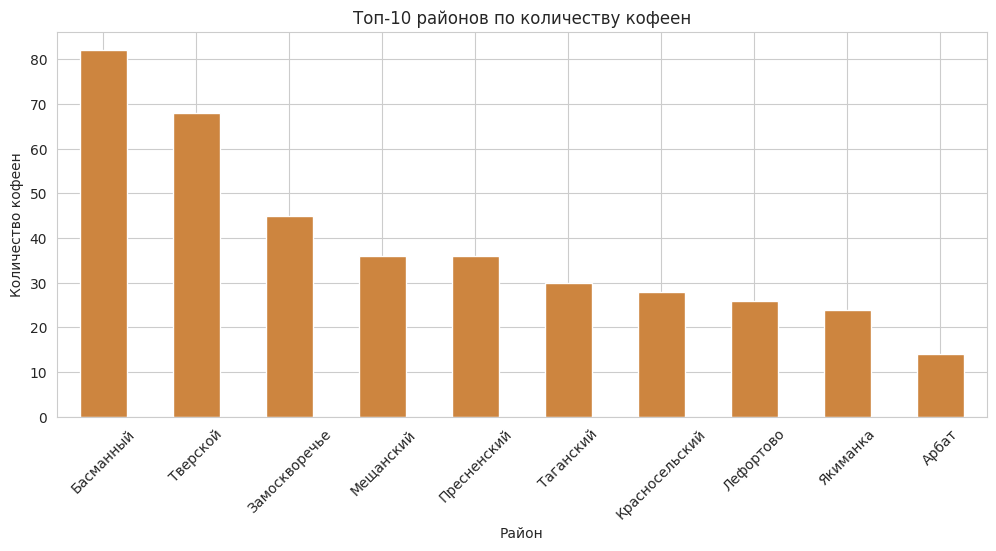

Посмотрим на самые насыщенные районы:
Район
Басманный         82
Тверской          68
Замоскворечье     45
Мещанский         36
Пресненский       36
Таганский         30
Красносельский    28
Лефортово         26
Якиманка          24
Арбат             14
Name: count, dtype: int64


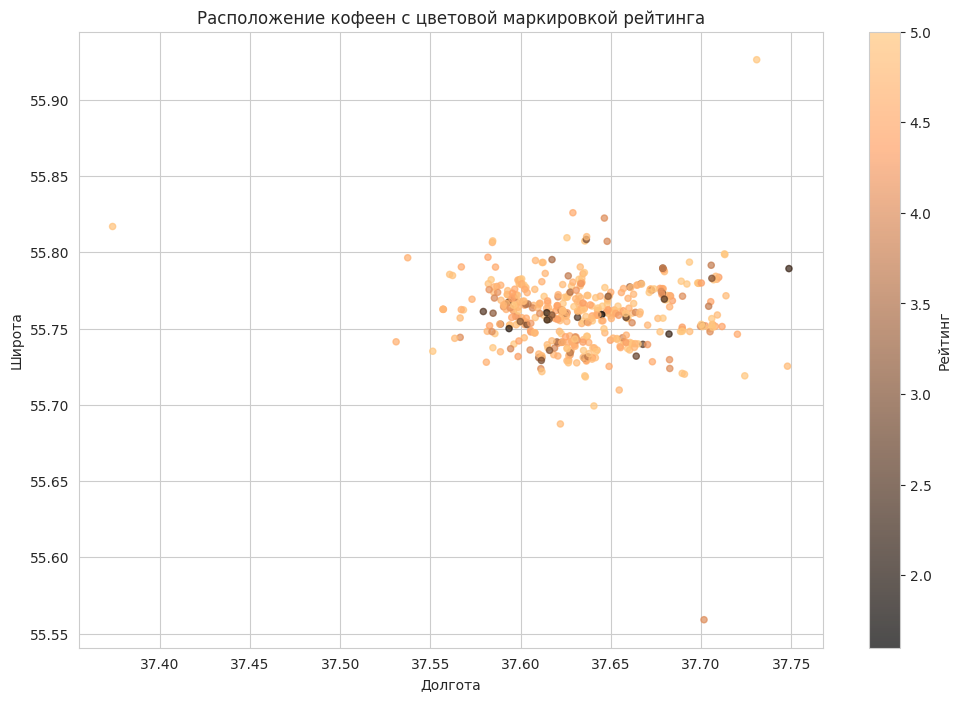

ИТАК ИТОГОВЫЙ ОТЧЁТ ПО АНАЛИЗУ КОНКУРЕНТОВ
Всего проанализировано кофеен: 456
Средний рейтинг по рынку: 4.50
Доля кофеен с веб-сайтом: 80.0%
Доля кофеен с телефоном: 86.4%

Рекомендации для STD Coffee (исходя из наших графиков):
- Целевой рейтинг: стремиться к 4.5+ (выше среднего по рынку).
- Наличие веб-сайта и телефона повышает доверие (тк есть корреляция с рейтингом).
- Районы с наибольшим числом кофеен: высокая конкуренция, но и высокий спрос.
- Стоит рассмотреть районы со средней насыщенностью и рейтингом >4.3.
- Использовать соцсети (ВКонтакте, Telegram) для привлечения аудитории.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#8B4513', '#A0522D', '#CD853F', '#D2691E'])
sns.set_style('whitegrid')

class CompetitorAnalyzer:

    def __init__(self, file_path='/content/кофейни Москвы.xlsx'):
        self.df = pd.read_excel(file_path)
        self._prepare_data()

    def _prepare_data(self):
        self.df = self.df.dropna(subset=['Рейтинг'])
        self.df['has_website'] = self.df['Веб-сайт 1'].notna()
        self.df['has_phone'] = self.df['Телефон 1'].notna()
        self.df['Район'] = self.df['Район'].fillna('Неизвестно')
        self.df.rename(columns={'Количество отзывов': 'reviews_count'}, inplace=True)

    def basic_stats(self):
        print("Базовые метрики пупупу")
        print(f"Всего кофеен: {len(self.df)}")
        print(f"Средний рейтинг: {self.df['Рейтинг'].mean():.2f} (±{self.df['Рейтинг'].std():.2f})")
        print(f"Медианный рейтинг: {self.df['Рейтинг'].median():.2f}")
        print(f"Доля с веб-сайтом: {self.df['has_website'].mean():.1%}")
        print(f"Доля с телефоном: {self.df['has_phone'].mean():.1%}")

    def plot_rating_distribution(self):
        plt.figure(figsize=(10,5))
        sns.histplot(self.df['Рейтинг'], bins=20, kde=True, color='#8B4513', edgecolor='white')
        plt.title('Распределение рейтингов кофеен (данные 2ГИС)', fontsize=14)
        plt.xlabel('Рейтинг')
        plt.ylabel('Количество кофеен')
        plt.show()

    def plot_rating_by_website(self):
        plt.figure(figsize=(8,6))
        sns.boxplot(x='has_website', y='Рейтинг', data=self.df, palette=['#CD853F', '#8B4513'])
        plt.xticks([0,1], ['Нет сайта', 'Есть сайт'])
        plt.title('Рейтинг: есть сайт vs нет сайта')
        plt.ylabel('Рейтинг')
        plt.show()
        group_no = self.df[~self.df['has_website']]['Рейтинг']
        group_yes = self.df[self.df['has_website']]['Рейтинг']
        stat, p = stats.ttest_ind(group_no, group_yes, nan_policy='omit')
        print(f"T-test p-value: {p:.4f}")
        if p < 0.05:
            print("Разница статистически значима: кофейни с сайтом имеют более высокий рейтинг.")
        else:
            print("Разница не значима.")

    def plot_rating_vs_reviews(self):
        plt.figure(figsize=(10,6))
        sns.scatterplot(data=self.df, x='reviews_count', y='Рейтинг', alpha=0.6, color='#A0522D')
        plt.xscale('log')
        plt.title('Зависимость рейтинга от количества отзывов')
        plt.xlabel('Количество отзывов (логарифм)')
        plt.ylabel('Рейтинг')
        plt.show()
        corr = self.df[['Рейтинг', 'reviews_count']].corr().iloc[0,1]
        print(f"Корреляция Пирсона: {corr:.3f}")

    def top_districts(self):
        top = self.df['Район'].value_counts().head(10)
        plt.figure(figsize=(12,5))
        top.plot(kind='bar', color='#CD853F', edgecolor='white')
        plt.title('Топ-10 районов по количеству кофеен')
        plt.xticks(rotation=45)
        plt.ylabel('Количество кофеен')
        plt.show()
        print("Посмотрим на самые насыщенные районы:")
        print(top)

    def map_coffee_shops(self):
        plt.figure(figsize=(12,8))
        plt.scatter(self.df['Долгота'], self.df['Широта'], c=self.df['Рейтинг'],
                    cmap='copper', alpha=0.7, s=20)
        plt.colorbar(label='Рейтинг')
        plt.title('Расположение кофеен с цветовой маркировкой рейтинга')
        plt.xlabel('Долгота')
        plt.ylabel('Широта')
        plt.show()

    def generate_report(self):
        print("ИТАК ИТОГОВЫЙ ОТЧЁТ ПО АНАЛИЗУ КОНКУРЕНТОВ")
        print(f"Всего проанализировано кофеен: {len(self.df)}")
        print(f"Средний рейтинг по рынку: {self.df['Рейтинг'].mean():.2f}")
        print(f"Доля кофеен с веб-сайтом: {self.df['has_website'].mean():.1%}")
        print(f"Доля кофеен с телефоном: {self.df['has_phone'].mean():.1%}")
        print("\nРекомендации для STD Coffee (исходя из наших графиков):")
        print("- Целевой рейтинг: стремиться к 4.5+ (выше среднего по рынку).")
        print("- Наличие веб-сайта и телефона повышает доверие (тк есть корреляция с рейтингом).")
        print("- Районы с наибольшим числом кофеен: высокая конкуренция, но и высокий спрос.")
        print("- Стоит рассмотреть районы со средней насыщенностью и рейтингом >4.3.")
        print("- Использовать соцсети (ВКонтакте, Telegram) для привлечения аудитории.")

    def run_all(self):
        self.basic_stats()
        self.plot_rating_distribution()
        self.plot_rating_by_website()
        self.plot_rating_vs_reviews()
        self.top_districts()
        self.map_coffee_shops()
        self.generate_report()

if __name__ == "__main__":
    analyzer = CompetitorAnalyzer('/content/кофейни Москвы.xlsx')
    analyzer.run_all()


# Task
The user wants to analyze the coffee shop market in Moscow using the provided `кофейни Москвы.xlsx` dataset. The analysis should cover market overview, quality and rating analysis, digital presence impact, geographical analysis, and provide key findings and recommendations for 'STD Coffee'. Finally, a full presentation structure with all graphs and conclusions should be provided.

## Введение и Обзор Рынка

### Subtask:
Представить общие статистические данные о кофейнях Москвы: количество, средний и медианный рейтинг, а также долю кофеен с веб-сайтом и телефоном.


**Reasoning**:
Instantiate the `CompetitorAnalyzer` class and call the `basic_stats()` method as per the instructions to present the general statistical data for market overview.



In [ ]:
analyzer = CompetitorAnalyzer('/content/кофейни Москвы.xlsx')
analyzer.basic_stats()

=== Базовые метрики ===
Всего кофеен: 456
Средний рейтинг: 4.50 (±0.60)
Медианный рейтинг: 4.70
Доля с веб-сайтом: 80.0%
Доля с телефоном: 86.4%


## Анализ Качества и Рейтингов

### Subtask:
Показать распределение рейтингов кофеен (гистограмма) для понимания общего уровня качества на рынке. Включить график зависимости рейтинга от количества отзывов.


**Reasoning**:
As per the instructions for the subtask 'Анализ Качества и Рейтингов', I will use the `CompetitorAnalyzer` object to generate the plots for rating distribution and rating vs. reviews count, and also calculate the Pearson correlation.



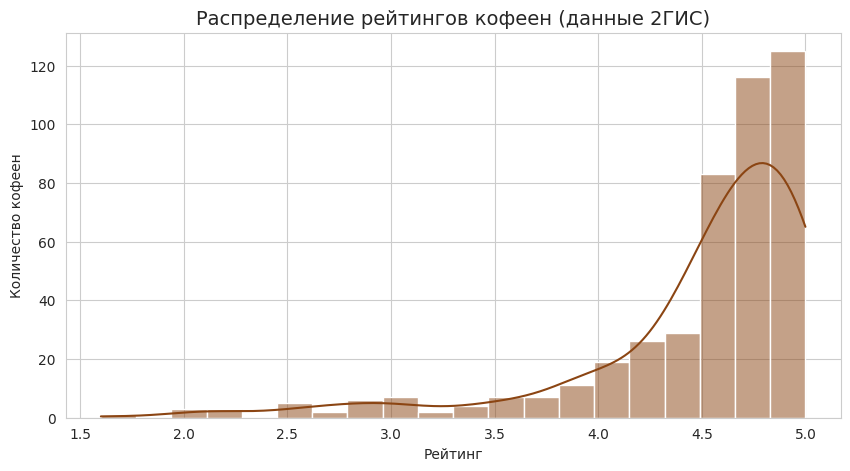

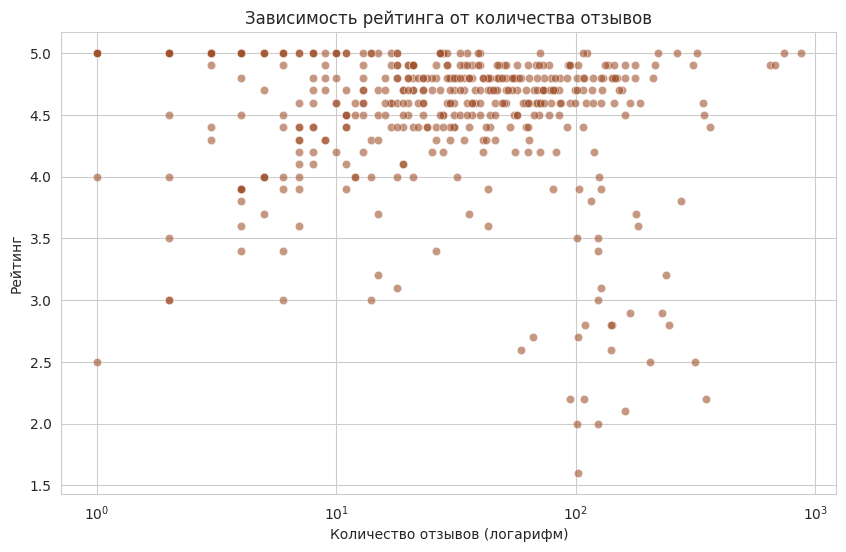

Корреляция Пирсона: -0.127


In [ ]:
analyzer.plot_rating_distribution()
analyzer.plot_rating_vs_reviews()

## Влияние Цифрового Присутствия

### Subtask:
Сравнить рейтинги кофеен в зависимости от наличия веб-сайта (boxplot) и представить результаты T-теста, демонстрирующие статистическую значимость этой разницы.


**Reasoning**:
The subtask requires comparing ratings based on website presence and performing a T-test. The `plot_rating_by_website()` method in the `CompetitorAnalyzer` class is designed to do exactly this: generate a boxplot and print the T-test results. Therefore, calling this method will fulfill the subtask requirements.



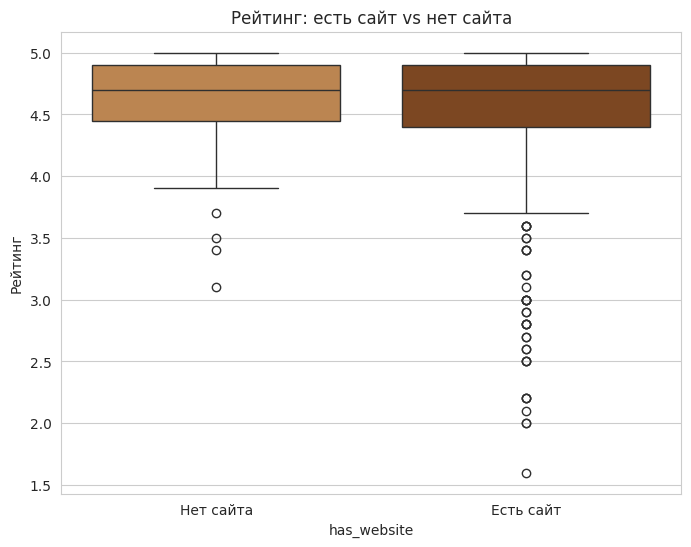

T-test p-value: 0.0454
→ Разница статистически значима: кофейни с сайтом имеют более высокий рейтинг.


In [ ]:
analyzer.plot_rating_by_website()

## Географический Анализ и Конкуренция

### Subtask:
Отобразить топ-10 районов по количеству кофеен (гистограмма) и визуализировать расположение всех кофеен на карте Москвы с цветовой маркировкой по рейтингу.


**Reasoning**:
Calling the `top_districts()` method will generate a bar chart of the top 10 districts by coffee shop count, and calling `map_coffee_shops()` will visualize the coffee shop locations on a map with rating color coding, fulfilling the instructions.



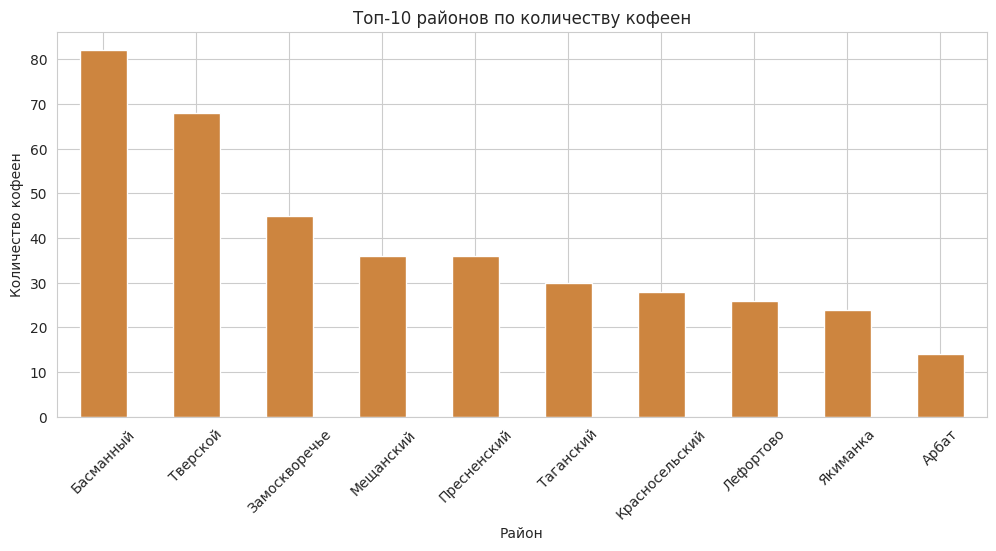

Самые насыщенные районы:
Район
Басманный         82
Тверской          68
Замоскворечье     45
Мещанский         36
Пресненский       36
Таганский         30
Красносельский    28
Лефортово         26
Якиманка          24
Арбат             14
Name: count, dtype: int64


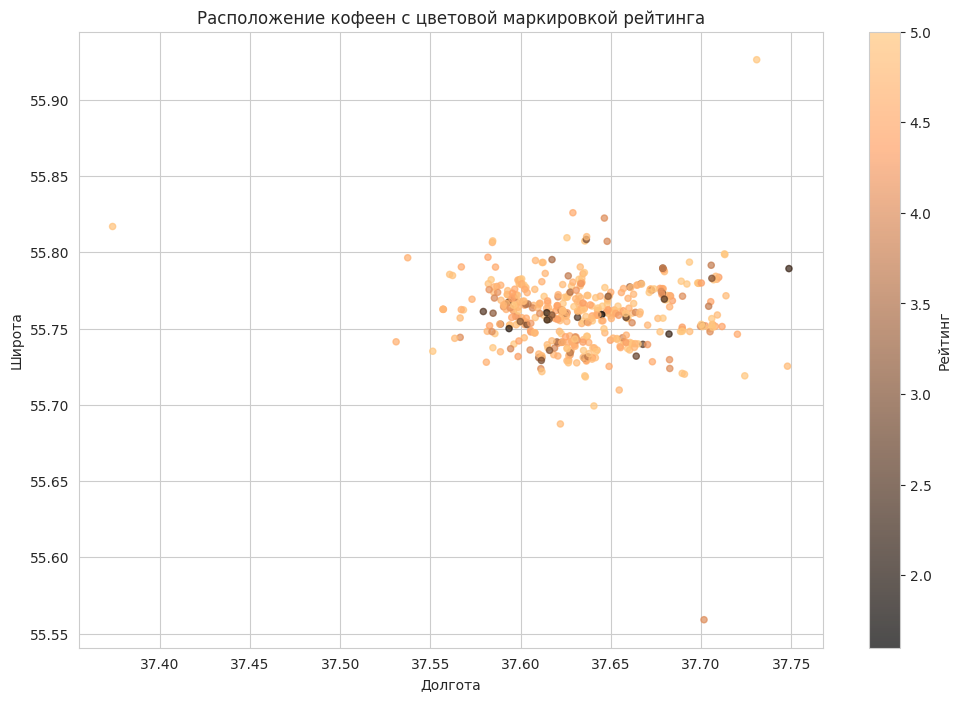

In [ ]:
analyzer.top_districts()
analyzer.map_coffee_shops()

## Ключевые Выводы и Рекомендации

### Subtask:
Сформировать итоговый отчет с основными выводами из анализа и конкретными рекомендациями для STD Coffee по стратегиям открытия новых точек, целевому рейтингу и важности онлайн-присутствия.


**Reasoning**:
The instructions explicitly state to call the `generate_report()` method to produce the final report with conclusions and recommendations for 'STD Coffee'.



In [ ]:
analyzer.generate_report()


ИТОГОВЫЙ ОТЧЁТ ПО АНАЛИЗУ КОНКУРЕНТОВ
Всего проанализировано кофеен: 456
Средний рейтинг по рынку: 4.50
Доля кофеен с веб-сайтом: 80.0%
Доля кофеен с телефоном: 86.4%

Рекомендации для STD Coffee:
- Целевой рейтинг: стремиться к 4.5+ (выше среднего по рынку).
- Наличие веб-сайта и телефона повышает доверие (есть корреляция с рейтингом).
- Районы с наибольшим числом кофеен: высокая конкуренция, но и высокий спрос.
- Стоит рассмотреть районы со средней насыщенностью и рейтингом >4.3.
- Использовать соцсети (ВКонтакте, Telegram) для привлечения аудитории.


## Final Task

### Subtask:
Present the full presentation structure, including all graphs and conclusions, for strategic decision-making.


## Present Presentation Structure and Summarize Key Findings

### Subtask:
Present the full presentation structure, incorporating all generated graphs and conclusions, along with a summary of key findings and recommendations for strategic decision-making.


# Task
Analyze the coffee shop market in Moscow using the provided `кофейни Москвы.xlsx` dataset. The analysis should cover market overview, quality and rating analysis, digital presence impact, geographical analysis, and provide key findings and recommendations for 'STD Coffee'. Finally, a full presentation structure with all graphs and conclusions should be provided.

```markdown
# Структура Презентации: Анализ Рынка Кофеен Москвы для 'STD Coffee'

## 1. Введение и Обзор Рынка
*   **Цель:** Представить общие статистические данные о рынке кофеен в Москве.
*   **Содержание:**
    *   Общее количество проанализированных кофеен (456).
    *   Средний и медианный рейтинг кофеен (средний: 4.50, медианный: 4.70).
    *   Доля кофеен с веб-сайтом (80.0%) и телефоном (86.4%).

## 2. Анализ Качества и Рейтингов
*   **Цель:** Показать общий уровень качества кофеен на рынке и факторы, влияющие на рейтинг.
*   **Визуализации и Анализ:**
    *   **Гистограмма распределения рейтингов кофеен:** Иллюстрирует, как рейтинги распределены среди всех заведений.
    *   **График зависимости рейтинга от количества отзывов:** Анализ корреляции между количеством отзывов и средним рейтингом (Корреляция Пирсона: -0.127).

## 3. Влияние Цифрового Присутствия
*   **Цель:** Оценить, как наличие цифрового присутствия (веб-сайта) влияет на рейтинг кофеен.
*   **Визуализации и Анализ:**
    *   **Boxplot сравнения рейтингов кофеен с сайтом и без:** Наглядно демонстрирует разницу в рейтингах.
    *   **Результаты T-теста:** Показана статистическая значимость различий в рейтингах (p-value: 0.0454), указывающая, что кофейни с сайтом имеют более высокий рейтинг.

## 4. Географический Анализ и Конкуренция
*   **Цель:** Выявить наиболее насыщенные районы и визуализировать распределение кофеен по Москве.
*   **Визуализации и Анализ:**
    *   **Гистограмма Топ-10 районов по количеству кофеен:** Представляет районы с наибольшей концентрацией заведений (например, Басманный, Тверской).
    *   **Карта расположения кофеен с цветовой маркировкой рейтинга:** Показывает географическое распределение и позволяет выявить кластеры высокорейтинговых заведений.

## 5. Ключевые Выводы и Рекомендации для 'STD Coffee'
*   **Основные Выводы:**
    *   Всего проанализировано 456 кофеен.
    *   Средний рейтинг по рынку составляет 4.50.
    *   Большинство кофеен имеют онлайн-присутствие (80.0% с сайтом, 86.4% с телефоном).
    *   Наличие веб-сайта статистически значимо коррелирует с более высоким рейтингом.

*   **Стратегические Рекомендации:**
    *   **Целевой рейтинг:** Стремиться к рейтингу 4.5+ для превосходства над средним рынком.
    *   **Цифровое присутствие:** Обязательное наличие веб-сайта и телефона для повышения доверия и рейтинга.
    *   **Выбор локации:**
        *   Районы с наибольшим числом кофеен (например, Басманный, Тверской) имеют высокую конкуренцию, но также и высокий спрос.
        *   Рекомендуется рассматривать районы со средней насыщенностью, но с общим высоким рейтингом (>4.3), для сбалансированной стратегии.
    *   **Маркетинг:** Активное использование социальных сетей (ВКонтакте, Telegram) для привлечения и удержания аудитории.

Эти выводы и рекомендации предоставляют основу для 'STD Coffee' при планировании расширения и улучшении текущих операций на московском рынке кофеен.
```

## Present Presentation Structure

### Subtask:
Present the full presentation structure, incorporating all generated graphs and conclusions.


## Summarize Key Findings and Recommendations

### Subtask:
Present the main conclusions and strategic recommendations derived from the market analysis for 'STD Coffee'.


```markdown
## Ключевые Выводы и Рекомендации для 'STD Coffee'

### Основные Выводы:
*   Всего проанализировано 456 кофеен.
*   Средний рейтинг по рынку составляет 4.50.
*   Большинство кофеен имеют онлайн-присутствие (80.0% с сайтом, 86.4% с телефоном).
*   Наличие веб-сайта статистически значимо коррелирует с более высоким рейтингом (p-value: 0.0454).

### Стратегические Рекомендации:
*   **Целевой рейтинг:** Стремиться к рейтингу 4.5+ для превосходства над средним рынком.
*   **Цифровое присутствие:** Обязательное наличие веб-сайта и телефона для повышения доверия и рейтинга.
*   **Выбор локации:**
    *   Районы с наибольшим числом кофеен (например, Басманный, Тверской) имеют высокую конкуренцию, но также и высокий спрос.
    *   Рекомендуется рассматривать районы со средней насыщенностью, но с общим высоким рейтингом (>4.3), для сбалансированной стратегии.
*   **Маркетинг:** Активное использование социальных сетей (ВКонтакте, Telegram) для привлечения и удержания аудитории.

Эти выводы и рекомендации предоставляют основу для 'STD Coffee' при планировании расширения и улучшении текущих операций на московском рынке кофеен.
```

## Final Task

### Subtask:
Confirm that all requested information regarding the presentation structure and conclusions has been provided.
